In [ ]:
# https://www.dataquest.io/blog/tutorial-time-series-analysis-with-pandas/
# https://machinelearningmastery.com/how-to-load-and-explore-household-electricity-usage-data/
# google pandas energy consumption

In [1]:
#  importar librerias
from numpy import *
import pandas as pd
import datetime
import seaborn as sns

pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import pyplot
import base64
from io import BytesIO

# ====================================================
# ====================================================


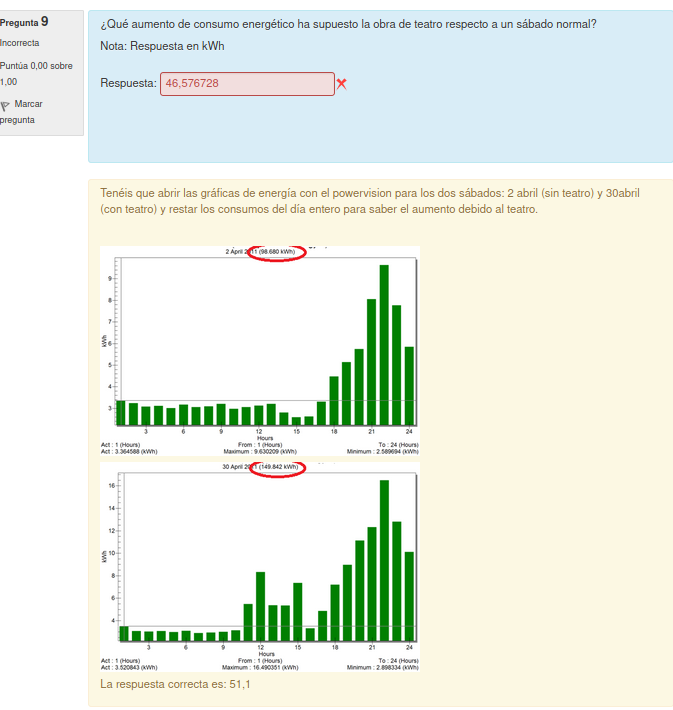
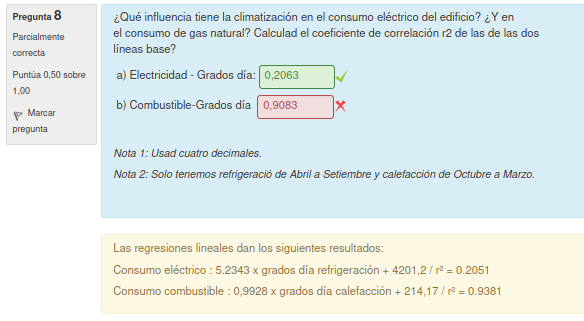
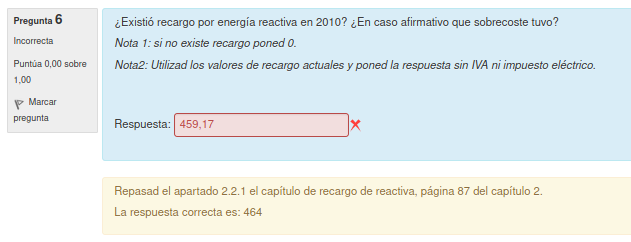

In [ ]:
# # Pregunta 9

# ¿Observáis en las mediciones o en la facturación algunos de los siguientes consumos ineficientes?
# Seleccione una o más de una:
# a. Consumos en horario matinal cuando el horario del centro es de tardes.
# b. Consumos nocturnos cuando el centro está cerrado.
# c. Puntas de potencia por encima de la contratada.
# d. Fases con intensidad nula.


In [2]:
import pandas as pd
df=pd.read_csv("datos/SB0.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df

,Date,Time,Period,Unit V,Unit A,Unit W,Voltage/Phase 1,Voltage/Phase 2,Voltage/Phase 3,Voltage/Phase III,...,Power factor/Phase 3 -,Power factor/Phase III +,Power factor/Phase III -,Energy/Active energy +,Energy/Active energy -,Energy/Reactive energy L +,Energy/Reactive energy L-,Energy/Reactive energy C +,Energy/Reactive energy C -,Frequency/Frequency
fechahora,,,,,,,,,,,,,,,,,,,,,
2011-03-31 13:39:22,03/31/2011,13:39:22,600,V,A,W,234,233,234,233,...,0.0,0.79,0.0,2.036813,0.0,1.545031,0.0,0.000951,0.0,50.0
2011-03-31 13:40:00,03/31/2011,13:40:00,600,V,A,W,234,233,234,233,...,0.0,0.79,0.0,2.787435,0.0,2.078276,0.0,0.000951,0.0,50.0
2011-03-31 13:50:00,03/31/2011,13:50:00,600,V,A,W,233,232,233,232,...,0.0,0.76,0.0,3.462683,0.0,2.603189,0.0,0.001663,0.0,50.0
2011-03-31 14:00:00,03/31/2011,14:00:00,600,V,A,W,232,231,231,231,...,0.0,0.75,0.0,4.196968,0.0,3.208319,0.0,0.001663,0.0,50.0
2011-03-31 14:10:00,03/31/2011,14:10:00,600,V,A,W,232,232,231,231,...,0.0,0.78,0.0,4.698330,0.0,3.570710,0.0,0.001663,0.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-04-08 10:40:00,04/08/2011,10:40:00,600,V,A,W,233,233,233,233,...,0.0,0.87,0.0,901.476006,0.0,541.406895,0.0,0.061828,0.0,50.0
2011-04-08 10:50:00,04/08/2011,10:50:00,600,V,A,W,233,232,232,232,...,0.0,0.80,0.0,902.110067,0.0,541.811082,0.0,0.061828,0.0,50.0
2011-04-08 11:00:00,04/08/2011,11:00:00,600,V,A,W,233,232,232,232,...,0.0,0.83,0.0,902.665723,0.0,542.118062,0.0,0.061828,0.0,50.0


In [137]:
df.columns

Index(['Date', 'Time', 'Period', 'Unit V', 'Unit A', 'Unit W',
       'Voltage/Phase 1', 'Voltage/Phase 2', 'Voltage/Phase 3',
       'Voltage/Phase III', 'Maximum voltage/Phase 1',
       'Maximum voltage/Phase 2', 'Maximum voltage/Phase 3',
       'Minimum voltage/Phase 1', 'Minimum voltage/Phase 2',
       'Minimum voltage/Phase 3', 'Current/Phase 1', 'Current/Phase 2',
       'Current/Phase 3', 'Current/Phase III', 'Maximum current/Phase 1',
       'Maximum current/Phase 2', 'Maximum current/Phase 3',
       'Minimum current/Phase 1', 'Minimum current/Phase 2',
       'Minimum current/Phase 3', 'Active power/Phase 1 +',
       'Active power/Phase 1 -', 'Active power/Phase 2 +',
       'Active power/Phase 2 -', 'Active power/Phase 3 +',
       'Active power/Phase 3 -', 'Active power/Phase III +',
       'Active power/Phase III -', 'Reactive power L/Phase 1 +',
       'Reactive power L/Phase 1 -', 'Reactive power L/Phase 2 +',
       'Reactive power L/Phase 2 -', 'Reactive power L/Ph

<AxesSubplot:xlabel='fechahora'>

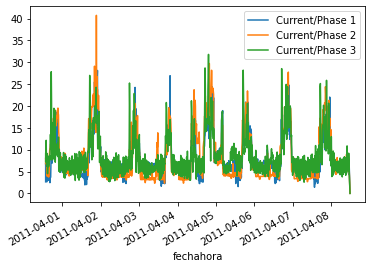

In [142]:
df[['Current/Phase 1','Current/Phase 2','Current/Phase 3']].plot()
# df[['Active power/Phase 1 -','Active power/Phase 2 -','Active power/Phase 3 -']].plot()

KeyError: 'weekday'

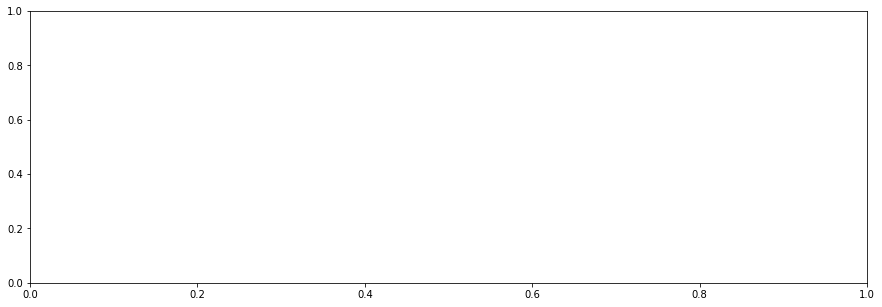

In [128]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax=df['Energy/Active energy +'].diff().groupby([df.index.hour,'weekday']).plot(ax=ax)

In [ ]:
# Pregunta 9
# Sin responder aún Puntúa como 1,00 Marcar pregunta Enunciado de la pregunta

# ¿Qué aumento de consumo energético ha supuesto la obra de teatro respecto a un sábado normal?

# Nota: Respuesta en kWh Respuesta:

In [72]:
ls datos

casopractico.ods               GD.csv    maximetro.csv   t_kwh.csv
cocina_manual_semana_tipo.csv  kvar.csv  SB0.csv
e_kwh.csv                      m2.csv    SB0-TEATRO.csv


<AxesSubplot:xlabel='fechahora'>

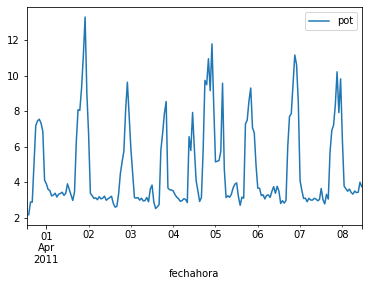

In [3]:
# crear serie temporal d la potencia diferenciando el resample horario de la energia
df=pd.read_csv("datos/SB0-TEATRO.csv", header=[0])
df=pd.read_csv("datos/SB0.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df=df[['Energy/Active energy +']]
df=df.resample('H').min()
# potencia a partir de la energia
df['pot']=df['Energy/Active energy +'].diff()
# df['pot'].iloc[0]=df['Energy/Active energy +'].iloc[0]

df=df[['pot']]
# df
df.plot()

fechahora
2011-04-02    99.508927
Freq: D, Name: pot, dtype: float64

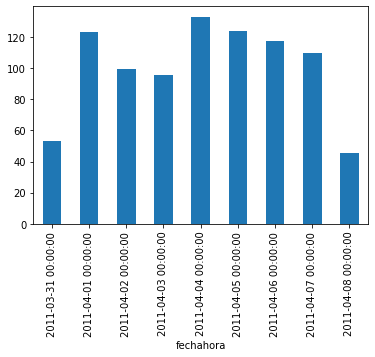

In [102]:
# crear serie temporal d la potencia diferenciando el resample horario de la energia
df=pd.read_csv("datos/SB0-TEATRO.csv", header=[0])
df=pd.read_csv("datos/SB0.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df=df[['Energy/Active energy +']]
df=df.resample('H').min()
# potencia a partir de la energia
df['pot']=df['Energy/Active energy +'].diff()
# df['pot'].iloc[0]=df['Energy/Active energy +'].iloc[0]

df=df[['pot']]
df=df.resample('D').sum()
df["Day"] = df.index.dayofweek
sabado1=df['pot'][df.Day==5]
# df
df['pot'].plot.bar()
sabado1


fechahora
2011-04-30    146.085655
Freq: D, Name: pot, dtype: float64

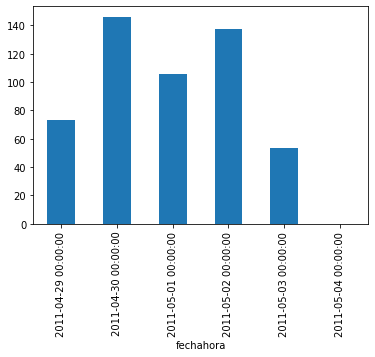

In [103]:
# crear serie temporal d la potencia diferenciando el resample horario de la energia
df=pd.read_csv("datos/SB0-TEATRO.csv", header=[0])
# df=pd.read_csv("datos/SB0.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df=df[['Energy/Active energy +']]
df=df.resample('H').min()
# potencia a partir de la energia
df['pot']=df['Energy/Active energy +'].diff()
# df['pot'].iloc[0]=df['Energy/Active energy +'].iloc[0]

df=df[['pot']]
df=df.resample('D').sum()
df["Day"] = df.index.dayofweek
sabado=df['pot'][df.Day==5]
# df
df['pot'].plot.bar()
sabado

In [105]:
146.085655-99.508927

46.576728

In [86]:
# crear serie temporal d la potencia diferenciando el resample horario de la energia
df=pd.read_csv("datos/SB0-TEATRO.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df=df[['Energy/Active energy +']]
df=df.resample('H').min()
# potencia a partir de la energia
df['pot']=df['Energy/Active energy +'].diff()
df['pot'].iloc[0]=df['Energy/Active energy +'].iloc[0]

df=df[['pot']]
# df
# horarios, festivos y fines de semana

df["Hour"] = df.index.hour
df["Day"] = df.index.dayofweek
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Q"] = df.index.quarter
df["Dayofyear"] = df.index.dayofyear
df["Dayofmonth"] = df.index.day
df["Drop_me"] = df.index.strftime("%m-%d")

# df["Weekofyear"] = df.index.weekofyear

def feature_holidays(row):
    if row["Drop_me"] == "01-01":
        return "New Year"
    if row["Drop_me"] == "04-07":
        return "Ind Day"
    if row["Drop_me"] == "11-28":
        return "Thanksgiving"
    if row["Drop_me"] == "12-25":
        return "Christmas"
    return 'Other'
def feature_worktime(row):
    if row["Hour"] > 7 & row["Hour"] <= 17:
        return "Worktime"
    return "NonWorkTime"
def feature_peak(row):
    if row["Hour"] > 7 & row["Hour"] <= 22:
        return "Peak"
    return "NonPeak"
def feature_weekend(row):
    if row["Day"] == 5 or row["Day"] == 6:
        return "Weekend"
    return "NonWeekend"
def dia_semana(row):
    if row["Day"] == 0 :
        return "lunes"
    if row["Day"] == 1 :
        return "martes"
    if row["Day"] == 2 :
        return "miercoles"
    if row["Day"] == 3 :
        return "jueves"
    if row["Day"] == 4 :
        return "viernes"
    if row["Day"] == 5 :
        return "sabado"
    if row["Day"] == 6 :
        return "domingo"
    return 'Other'
# 
df["Holiday"] = df.apply (lambda row : feature_holidays(row), axis=1)
df["Work"] = df.apply(lambda row: feature_worktime(row), axis=1)
df["Peak"] = df.apply(lambda row: feature_peak(row), axis=1)
df["Weekend"] = df.apply(lambda row: feature_weekend(row), axis=1)
df["dia_semana"] = df.apply(lambda row: dia_semana(row), axis=1)
df

,pot,Hour,Day,Month,Year,Q,Dayofyear,Dayofmonth,Drop_me,Holiday,Work,Peak,Weekend,dia_semana
fechahora,,,,,,,,,,,,,,
2011-04-29 12:00:00,916.728997,12,4,4,2011,2,119,29,04-29,Other,Worktime,Peak,NonWeekend,viernes
2011-04-29 13:00:00,0.232235,13,4,4,2011,2,119,29,04-29,Other,Worktime,Peak,NonWeekend,viernes
2011-04-29 14:00:00,3.218606,14,4,4,2011,2,119,29,04-29,Other,Worktime,Peak,NonWeekend,viernes
2011-04-29 15:00:00,3.520943,15,4,4,2011,2,119,29,04-29,Other,Worktime,Peak,NonWeekend,viernes
2011-04-29 16:00:00,3.086915,16,4,4,2011,2,119,29,04-29,Other,Worktime,Peak,NonWeekend,viernes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-05-04 06:00:00,NaN,6,2,5,2011,2,124,4,05-04,Other,NonWorkTime,NonPeak,NonWeekend,miercoles
2011-05-04 07:00:00,NaN,7,2,5,2011,2,124,4,05-04,Other,NonWorkTime,NonPeak,NonWeekend,miercoles
2011-05-04 08:00:00,NaN,8,2,5,2011,2,124,4,05-04,Other,Worktime,Peak,NonWeekend,miercoles


In [ ]:
# ¿Qué influencia tiene la climatización en el consumo eléctrico del edificio? ¿Y en
# el consumo de gas natural? Calculad el coeficiente de correlación r2 de las de las dos
# líneas base?

#  a) Electricidad - Grados día:
# Respuesta

#  b) Combustible-Grados día  
# Respuesta



# Nota 1: Usad cuatro decimales.

# Nota 2: Solo tenemos refrigeració de Abril a Setiembre y calefacción de Octubre a Marzo.

In [3]:
# Ejercicio caso real (II): cálculo de Baselines p63
# python trendline linear regression coefficient of determination
# https://en.wikipedia.org/wiki/Linear_regression
# ///////////////////////////////////////////////
#  definir en las tablas las variables
import numpy as np
import pandas as pd
import datetime

pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import base64
from io import BytesIO


In [65]:
# electrico total
dfa=pd.read_csv("datos/e_kwh.csv", header=[0])

dfa=dfa.loc[dfa.ano==2010]
dfa=dfa.set_index('mes')
dfa=dfa.drop(['ano'], axis=1)
dfa['P']=dfa.T.sum()
dfa
y=dfa.P



In [66]:
dfg

,mesn,kWh,fijo,variable
mes,,,,
1,Enero,533,"7,84","0,03725"
2,Febrero,482,"7,84","0,03725"
3,Marzo,367,"7,84","0,03803"
4,Abril,275,"7,84","0,03803"
5,Mayo,202,"7,84","0,03880"
6,Junio,195,"7,84","0,03880"
7,Julio,202,"7,84","0,04195"
8,Agosto,202,"7,84","0,04195"
9,Septiembre,195,"7,84","0,04164"


In [69]:
c=[1,1,1,0,0,0,0,0,0,1,1,1]
r=[0,0,0,1,1,1,1,1,1,0,0,0]
gd=pd.read_csv("datos/GD.csv", header=[0])
gd=gd.set_index('mes')
gd
x=gd.GDr21*r
x

mes
1       0
2       0
3       0
4       3
5      16
6      69
7     129
8     133
9      59
10      0
11      0
12      0
Name: GDr21, dtype: int64

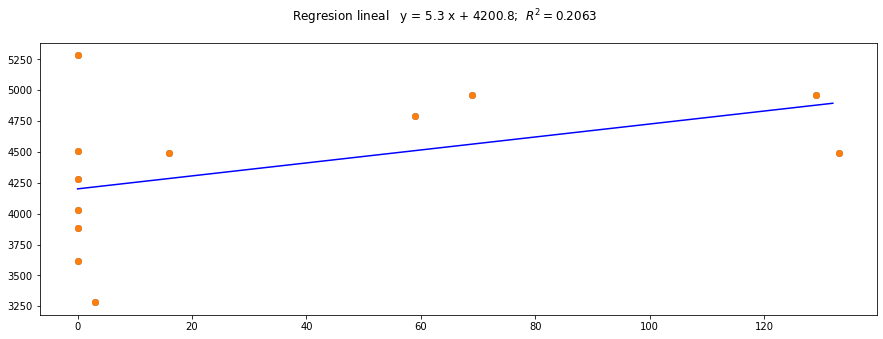

In [70]:



# Polynomial Regression
def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)

     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    # r-squared
    p = np.poly1d(coeffs)
    # fit values, and mean
    yhat = p(x)                         # or [p(z) for z in x]
    ybar = np.sum(y)/len(y)          # or sum(y)/len(y)
    ssreg = np.sum((yhat-ybar)**2)   # or sum([ (yihat - ybar)**2 for yihat in yhat])
    sstot = np.sum((y - ybar)**2)    # or sum([ (yi - ybar)**2 for yi in y])
    results['determination'] = ssreg / sstot

    return results
degree=1
model=np.polyfit(x, y, degree)
predict = np.poly1d(model)
model1= polyfit(x, y, degree)
m=round(model1['polynomial'][0],1)
b=round(model1['polynomial'][1],1)
R2=round(model1['determination'],4)


tt='Regresion lineal   y = '+str(m)+' x + '+str(b)+';  $R^2=$'+str(R2)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.scatter(x,y)
ax = plt.suptitle(tt)
# ax = plt.ylabel("kwh")
x_lin_reg = range(0, x.max())
y_lin_reg = predict(x_lin_reg)
ax = plt.scatter(x, y)
ax = plt.plot(x_lin_reg, y_lin_reg, c = 'b')

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
# plt.close()

In [26]:
# calefaccion

In [62]:
# gas total
dfg=pd.read_csv("datos/t_kwh.csv", header=[0])
dfg=dfg.set_index('mes')
y=dfg.kWh*(1-0.489775)

dfg

,mesn,kWh,fijo,variable
mes,,,,
1,Enero,533,"7,84","0,03725"
2,Febrero,482,"7,84","0,03725"
3,Marzo,367,"7,84","0,03803"
4,Abril,275,"7,84","0,03803"
5,Mayo,202,"7,84","0,03880"
6,Junio,195,"7,84","0,03880"
7,Julio,202,"7,84","0,04195"
8,Agosto,202,"7,84","0,04195"
9,Septiembre,195,"7,84","0,04164"


In [63]:
c=[1,1,1,0,0,0,0,0,0,1,1,1]
r=[0,0,0,1,1,1,1,1,1,0,0,0]
gd=pd.read_csv("datos/GD.csv", header=[0])
gd=gd.set_index('mes')
gd
x=gd.GDc18*c
x




mes
1     314
2     295
3     213
4       0
5       0
6       0
7       0
8       0
9       0
10     62
11    167
12    295
Name: GDc18, dtype: int64

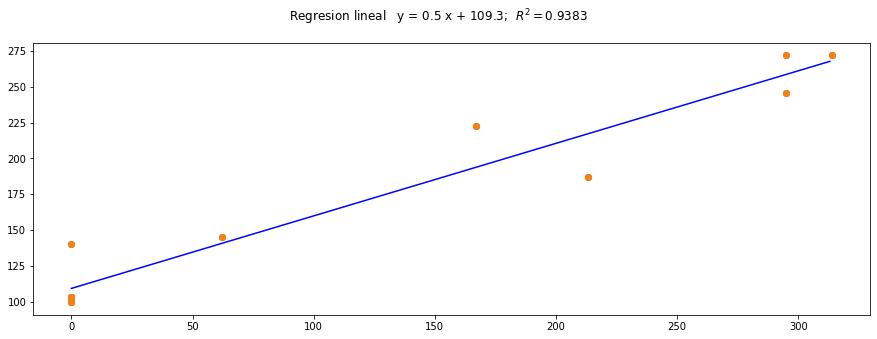

In [64]:
# Polynomial Regression
def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)

     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    # r-squared
    p = np.poly1d(coeffs)
    # fit values, and mean
    yhat = p(x)                         # or [p(z) for z in x]
    ybar = np.sum(y)/len(y)          # or sum(y)/len(y)
    ssreg = np.sum((yhat-ybar)**2)   # or sum([ (yihat - ybar)**2 for yihat in yhat])
    sstot = np.sum((y - ybar)**2)    # or sum([ (yi - ybar)**2 for yi in y])
    results['determination'] = ssreg / sstot

    return results
degree=1
model=np.polyfit(x, y, degree)
predict = np.poly1d(model)
model1= polyfit(x, y, degree)
m=round(model1['polynomial'][0],1)
b=round(model1['polynomial'][1],1)
R2=round(model1['determination'],4)


tt='Regresion lineal   y = '+str(m)+' x + '+str(b)+';  $R^2=$'+str(R2)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.scatter(x,y)
ax = plt.suptitle(tt)
# ax = plt.ylabel("kwh")
x_lin_reg = range(0, x.max())
y_lin_reg = predict(x_lin_reg)
ax = plt.scatter(x, y)
ax = plt.plot(x_lin_reg, y_lin_reg, c = 'b')

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
# plt.close()

In [2]:
# # Pregunta 7

# En 2010 el consumo del bar representó un
# Respuesta
# % del consumo eléctrico total y un
# Respuesta
# % del consumo de gas natural total.

In [3]:
ls datos

casopractico.ods               GD.csv    maximetro.csv   t_kwh.csv
cocina_manual_semana_tipo.csv  kvar.csv  SB0.csv
e_kwh.csv                      m2.csv    SB0-TEATRO.csv


,total,cocina,%
electrico,52558,20423.4,38.8588
gas,3906,1913.06,48.9775


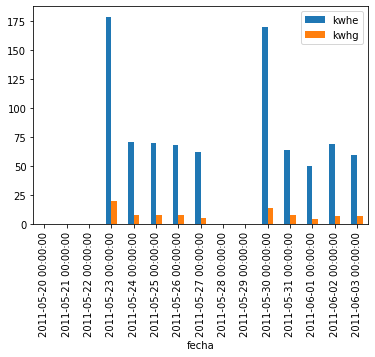

In [99]:
# habria qeu interpolar para sacar los dias que no han tomado lectura manual
# para meter los resultados
# PCI gas natural: 11,52 kWh/m³

cc=pd.DataFrame(index=['total','cocina'],columns=['electrico','gas'])
# 
df=pd.read_csv("datos/cocina_manual_semana_tipo.csv", header=[0])
df['fecha']=pd.to_datetime(df['fecha'],format='%d/%m/%Y')
df=df.set_index('fecha')
df['kwhe']=df['Contador electricidad'].diff()
df['kwhg']=df['Contador gas'].diff()*11.52
df['dia']=df.index.dayofweek
# df
# para meter los dias que faltan
df=df.resample('D').min()
# df['kwhe'].plot.bar()
# el consumo de todo el ano sera el de una semana por el numero dce semanas del ano, 
# menos las cuatro semanas que esa cerrado
cc.at['cocina','electrico']=df['kwhe'].tail(7).sum()*(375/7-4)
cc.at['cocina','gas']=df['kwhg'].tail(7).sum()*(375/7-4)

# electrico total
dfa=pd.read_csv("datos/e_kwh.csv", header=[0])

dfa=dfa.loc[dfa.ano==2010]
dfa=dfa.set_index('mes')
dfa=dfa.drop(['ano'], axis=1)

cc.at['total','electrico']=dfa.sum().sum()

# gas total
dfg=pd.read_csv("datos/t_kwh.csv", header=[0])
cc.at['total','gas']=dfg.sum().kWh
cc=cc.T
cc['%']=cc.cocina/cc.total*100

df[['kwhe','kwhg']].plot.bar()
cc

In [3]:
# # Pregunta 6

# ¿Existió recargo por energía reactiva en 2010? ¿En caso afirmativo que sobrecoste tuvo?
# Nota 1: si no existe recargo poned 0.
# Nota 2: Utilizad los valores de recargo actuales y poned la respuesta sin IVA ni impuesto eléctrico.
# Respuesta:


In [4]:
#  importar librerias
from numpy import *
import pandas as pd
import datetime
import seaborn as sns

pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import pyplot
import base64
from io import BytesIO

# ====================================================
# ====================================================


dfa=pd.read_csv("datos/e_kwh.csv", header=[0])

dfa=dfa.loc[dfa.ano==2010]
dfa=dfa.set_index('mes')
dfa=dfa.drop(['ano'], axis=1)
dfa['P1']=dfa.p1+dfa.p4
dfa['P2']=dfa.p2+dfa.p5

dfr=pd.read_csv("datos/kvar.csv", header=[0])
dfr=dfr.loc[dfr.ano==2010]
dfr=dfr.set_index('mes')
dfr=dfr.drop(['ano'], axis=1)
dfr['P1']=dfr.p1+dfr.p4
dfr['P2']=dfr.p2+dfr.p5
# 
dfr=dfr.astype(float)
dfa=dfa.astype(float)
# 
df=pd.DataFrame()
df['mes']=dfr.index
df=df.set_index('mes')

df['e1']=where(dfr.P1-dfa.P1/3 < 0,0,dfr.P1-dfa.P1/3 )
df['e2']=where(dfr.P2-dfa.P2/3 < 0,0,dfr.P2-dfa.P2/3 )

# 

df['cfi1']=cos(arctan(dfr.P1/dfa.P1))
df['cfi2']=cos(arctan(dfr.P2/dfa.P2))

# 
df['rec1']= where(df.cfi1 >= 0.95,0,where(df.cfi1 <= 0.80,0.062332 ,0.041554 ))
df['rec2']= where(df.cfi2 >= 0.95,0,where(df.cfi2 <= 0.80,0.062332 ,0.041554 ))
# 
df['rect1']=df.e1*df.rec1
df['rect2']=df.e2*df.rec2
# 
recargo_total=df.sum().rect1+df.sum().rect2
recargo_total
df

,e1,e2,cfi1,cfi2,rec1,rec2,rect1,rect2
mes,,,,,,,,
1,206.333333,310.666667,0.894282,0.896728,0.041554,0.041554,8.573975,12.909443
2,216.666667,245.000000,0.891685,0.902179,0.041554,0.041554,9.003367,10.180730
3,247.333333,328.333333,0.880798,0.890230,0.041554,0.041554,10.277689,13.643563
4,92.000000,558.000000,0.871050,0.857996,0.041554,0.041554,3.822968,23.187132
5,151.666667,797.000000,0.856823,0.855503,0.041554,0.041554,6.302357,33.118538
6,211.000000,932.666667,0.840004,0.843254,0.041554,0.041554,8.767894,38.756031
7,211.000000,932.666667,0.840004,0.843254,0.041554,0.041554,8.767894,38.756031
8,374.000000,888.000000,0.787205,0.802572,0.062332,0.041554,23.312168,36.899952
9,254.333333,1013.000000,0.818282,0.824411,0.041554,0.041554,10.568567,42.094202


In [6]:
# Si se hace separando los periodos

In [7]:
df=pd.DataFrame()
df['e1']=where(dfr.p1-dfa.p1/3 < 0,0,dfr.p1-dfa.p1/3 )
df['e2']=where(dfr.p2-dfa.p2/3 < 0,0,dfr.p2-dfa.p2/3 )
df['e4']=where(dfr.p4-dfa.p4/3 < 0,0,dfr.p4-dfa.p4/3 )
df['e5']=where(dfr.p5-dfa.p5/3 < 0,0,dfr.p5-dfa.p5/3 )
# 
df['cfi1']=cos(arctan(dfr.p1/dfa.p1))
df['cfi2']=cos(arctan(dfr.p2/dfa.p2))
df['cfi4']=cos(arctan(dfr.p4/dfa.p4))
df['cfi5']=cos(arctan(dfr.p5/dfa.p5))
# 
df['rec1']= where(df.cfi1 >= 0.95,0,where(df.cfi1 <= 0.80,0.062332 ,0.041554 ))
df['rec2']= where(df.cfi2 >= 0.95,0,where(df.cfi2 <= 0.80,0.062332 ,0.041554 ))
df['rec4']= where(df.cfi4 >= 0.95,0,where(df.cfi4 <= 0.80,0.062332 ,0.041554 ))
df['rec5']= where(df.cfi5 >= 0.95,0,where(df.cfi5 <= 0.80,0.062332 ,0.041554 ))
# 
df['rect1']=df.e1*df.rec1
df['rect2']=df.e2*df.rec2
df['rect4']=df.e4*df.rec4
df['rect5']=df.e5*df.rec5
# 
recargo_total=df.sum().rect1+df.sum().rect2+df.sum().rect4+df.sum().rect5
recargo_total


# df

473.21107599999993

In [8]:
df

,e1,e2,e4,e5,cfi1,cfi2,cfi4,cfi5,rec1,rec2,rec4,rec5,rect1,rect2,rect4,rect5
0,158.333333,240.000000,48.000000,70.666667,NaN,NaN,NaN,NaN,0.041554,0.041554,0.041554,0.041554,6.579383,9.972960,1.994592,2.936483
1,190.000000,207.000000,26.666667,38.000000,0.892276,0.893286,0.900016,0.905831,0.041554,0.041554,0.041554,0.041554,7.895260,8.601678,1.108107,1.579052
2,210.333333,275.000000,37.000000,53.333333,0.886143,0.897036,0.913968,0.918661,0.041554,0.041554,0.041554,0.041554,8.740191,11.427350,1.537498,2.216213
3,67.000000,477.666667,25.000000,80.333333,0.873939,0.883247,0.904358,0.911199,0.041554,0.041554,0.041554,0.041554,2.784118,19.848961,1.038850,3.338171
4,104.333333,648.000000,47.333333,149.000000,0.870281,0.847472,0.873042,0.893291,0.041554,0.041554,0.041554,0.041554,4.335467,26.926992,1.966889,6.191546
5,147.000000,724.000000,64.000000,208.666667,0.854502,0.839308,0.861575,0.892779,0.041554,0.041554,0.041554,0.041554,6.108438,30.085096,2.659456,8.670935
6,147.000000,724.000000,64.000000,208.666667,0.842431,0.839687,0.834019,0.854090,0.041554,0.041554,0.041554,0.041554,6.108438,30.085096,2.659456,8.670935
7,240.666667,571.333333,133.333333,316.666667,0.842431,0.839687,0.834019,0.854090,0.041554,0.041554,0.041554,0.041554,10.000663,23.741185,5.540533,13.158767
8,195.666667,795.333333,58.666667,217.666667,0.795562,0.799860,0.769861,0.807242,0.062332,0.062332,0.062332,0.041554,12.196295,49.574717,3.656811,9.044921
9,130.000000,676.666667,71.666667,220.000000,0.816362,0.818572,0.824332,0.842142,0.041554,0.041554,0.041554,0.041554,5.402020,28.118207,2.978037,9.141880


In [ ]:
# Pregunta 5
# Sin responder aún
# Puntúa como 1,00
# Marcar pregunta
# Enunciado de la pregunta

# La potencia óptima a contratar seria de
# Respuesta
# kW que comportaría un ahorro anual de
# Respuesta
# €

# Nota: suponemos la misma potencia de contratada en cada período y los valores de maxímetro de 2010.

# Nota: El ahorro sin IVA ni impuesto eléctrico. Para calcular usar los precios de potencia de 2.014


In [ ]:
# 
df=pd.read_csv("datos/maximetro.csv", header=[0])
df['diasmes']=[31,28,31,30,31,30,31,31,30,31,30,31]
aa=df.describe()
# aa
pc=43.64 #kW


# para buscar el punto en cuyo contorno debe estar el minimo parto de la mdeia de los valores
p=['p1','p2','p3']
pcm=int(aa.loc['mean',p].mean()*10)
# pcm



# df=pd.read_csv("datos/maximetro.csv", header=[0])
# medida Pi
df['P1']=df[["p1", "p4"]].max(axis=1)
df['P2']=df[["p2", "p5"]].max(axis=1)
df['P3']=df[["p3", "p6"]].max(axis=1)
# a facturar
def coste(pc):
    pp='P1'
    df["f1"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    pp='P2'
    df["f2"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    pp='P3'
    df["f3"]=where(df[pp] <  0.85*pc,0.85*pc,
                    where((df[pp] >= 0.85*pc) & (df[pp] <= 1.05*pc),df[pp],
                          where(df[pp] >  1.05*pc,df[pp]+2*(df[pp]-1.05*pc),0)))
    s1=0.111585986 # €/kW dia 
    s2=0.066951589 # €/kW dia 
    s3=0.044634397 # €/kW dia
    df["S1"]=df["f1"]*s1*df['diasmes']
    df["S2"]=df["f2"]*s2*df['diasmes']
    df["S3"]=df["f3"]*s3*df['diasmes']
    S=df.sum().S1+df.sum().S2+df.sum().S3
    return S



# para encontrar el optmo
# /////////////////////////////////////////////////////
# df[['pm1','pf1']]
SS=[]
xx=[]
# pc=pc*100 #kW
for x in range(pcm-100, pcm+300):
    poo=x/10 #kW
    S=coste(poo)
    SS.append(S)
    xx.append(x/10)
# ////////////////////////////////////////////////////
#     
dx=pd.DataFrame()
dx["Potencia_contratada"]=xx
dx["Coste_anual"]=SS

Smin = dx['Coste_anual'].min()
indice = dx['Coste_anual'].idxmin()
po=dx.loc[indice,"Potencia_contratada"]
# resultados

Spc=coste(pc)
Spo=coste(po)

ii=['Potencia ($kW$)','Coste (€)']
cc = ["contratada",'optima']
qq=pd.DataFrame(columns=cc,index=ii)    
qq['contratada']=[pc,round(Spc,1)]
qq['optima']=[po,round(Spo,1)]
qq['    $\Delta$']=qq.contratada-qq.optima
qq['    %']=round((qq.contratada-qq.optima)/qq.contratada*100,1)



# pra representar la funcion de coste
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.plot(xx,SS)
ax = plt.suptitle('Optimizacion de potencia contratada')
ax = plt.ylabel("€")
ax = plt.xlabel("kW")
# html = qq.to_markdown()
ax=plt.text(po, Spo*1.08, str(qq))
qq

In [ ]:
df=pd.read_csv("datos/e_kwh.csv", header=[0])
# df

In [ ]:
p=['p1','p2','p3','p4','p5','p6']
df=df.loc[df.ano==2010]
df['kwh']=df[p].T.sum()
df.plot.bar(x='mes', y='kwh', style='o')

In [ ]:
df.sum().kwh/1001

In [ ]:
df=pd.read_csv("datos/t_kwh.csv", header=[0])
df['kWh'].plot.bar()


In [ ]:
dd=pd.read_csv("datos/GD.csv", header=[0])
dd
dd['GDcal18oC'].plot.bar()

In [ ]:
df['GDcal18oC']=dd['GDcal18oC']
df['g_kwh/GD']=df['kWh']/dd['GDcal18oC']
aa=df.sum()
kWh_GD=aa.kWh/aa.GDcal18oC
kWh_GD

In [ ]:
df

In [ ]:
df

In [ ]:
df=pd.read_csv("datos/cocina_manual_semana_tipo.csv", header=[0])
df['fechahora']=pd.to_datetime(df['fecha'])
df=df.set_index('fechahora')
df

In [ ]:
df['e_pot']=df['Contador electricidad'].diff()
# df['e_pot'].iloc[0]=df['Contador electricidad'].iloc[0]
df['e_pot'].iloc[0]=0

df['t_pot']=df['Contador gas'].diff()
# df['e_pot'].iloc[0]=df['Contador electricidad'].iloc[0]
df['t_pot'].iloc[0]=0
pcg=11.52 #kWh/m3
df['t_pot']=df['t_pot']*pcg


In [ ]:
df["Day"] = df.index.dayofweek
df

In [ ]:
# horarios, festivos y fines de semana

df["Hour"] = df.index.hour
df["Day"] = df.index.dayofweek
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Q"] = df.index.quarter
df["Dayofyear"] = df.index.dayofyear
df["Dayofmonth"] = df.index.day
df["Drop_me"] = df.index.strftime("%m-%d")

# df["Weekofyear"] = df.index.weekofyear

def feature_holidays(row):
    if row["Drop_me"] == "01-01":
        return "New Year"
    if row["Drop_me"] == "04-07":
        return "Ind Day"
    if row["Drop_me"] == "11-28":
        return "Thanksgiving"
    if row["Drop_me"] == "12-25":
        return "Christmas"
    return 'Other'
def feature_worktime(row):
    if row["Hour"] > 7 & row["Hour"] <= 17:
        return "Worktime"
    return "NonWorkTime"
def feature_peak(row):
    if row["Hour"] > 7 & row["Hour"] <= 22:
        return "Peak"
    return "NonPeak"
def feature_weekend(row):
    if row["Day"] == 5 or row["Day"] == 6:
        return "Weekend"
    return "NonWeekend"
def dia_semana(row):
    if row["Day"] == 0 :
        return "lunes"
    if row["Day"] == 1 :
        return "martes"
    if row["Day"] == 2 :
        return "miercoles"
    if row["Day"] == 3 :
        return "jueves"
    if row["Day"] == 4 :
        return "viernes"
    if row["Day"] == 5 :
        return "sabado"
    if row["Day"] == 6 :
        return "domingo"
    return 'Other'
# 
df["Holiday"] = df.apply (lambda row : feature_holidays(row), axis=1)
df["Work"] = df.apply(lambda row: feature_worktime(row), axis=1)
df["Peak"] = df.apply(lambda row: feature_peak(row), axis=1)
df["Weekend"] = df.apply(lambda row: feature_weekend(row), axis=1)
df["dia_semana"] = df.apply(lambda row: dia_semana(row), axis=1)

In [ ]:
df['e_pot'].plot.bar()


In [ ]:
df['t_pot'].plot.bar()

In [ ]:
# # Pregunta 3
# Sin responder aún
# Puntúa como 1,00
# Marcar pregunta
# Enunciado de la pregunta

# ¿Según las facturas que proporción del consumo eléctrico anual es en fin de semana en 2010?
df=pd.read_csv("datos/e_kwh.csv", header=[0])
df=df.loc[df['ano'] == 2010]


In [ ]:
df['p']=df[['p1','p2','p3','p4','p5','p6']].T.sum()
df['pl']=df[['p1','p2','p3']].T.sum()
df['pf']=df[['p4','p5','p6']].T.sum()


In [ ]:
aa=df.sum()

In [ ]:
aa.pf/aa.p,aa.pl/aa.p,

In [129]:
# crear serie temporal d la potencia diferenciando el resample horario de la energia
df=pd.read_csv("datos/SB0.csv", header=[0])
df['fechahora']=pd.to_datetime(df['Date'] + ' ' + df['Time'])
df=df.set_index('fechahora')
df=df[['Energy/Active energy +']]
df=df.resample('H').min()
# potencia a partir de la energia
df['pot']=df['Energy/Active energy +'].diff()
df['pot'].iloc[0]=df['Energy/Active energy +'].iloc[0]

df=df[['pot']]
# df
# horarios, festivos y fines de semana

df["Hour"] = df.index.hour
df["Day"] = df.index.dayofweek
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Q"] = df.index.quarter
df["Dayofyear"] = df.index.dayofyear
df["Dayofmonth"] = df.index.day
df["Drop_me"] = df.index.strftime("%m-%d")

# df["Weekofyear"] = df.index.weekofyear

def feature_holidays(row):
    if row["Drop_me"] == "01-01":
        return "New Year"
    if row["Drop_me"] == "04-07":
        return "Ind Day"
    if row["Drop_me"] == "11-28":
        return "Thanksgiving"
    if row["Drop_me"] == "12-25":
        return "Christmas"
    return 'Other'
def feature_worktime(row):
    if row["Hour"] > 7 & row["Hour"] <= 17:
        return "Worktime"
    return "NonWorkTime"
def feature_peak(row):
    if row["Hour"] > 7 & row["Hour"] <= 22:
        return "Peak"
    return "NonPeak"
def feature_weekend(row):
    if row["Day"] == 5 or row["Day"] == 6:
        return "Weekend"
    return "NonWeekend"
def dia_semana(row):
    if row["Day"] == 0 :
        return "lunes"
    if row["Day"] == 1 :
        return "martes"
    if row["Day"] == 2 :
        return "miercoles"
    if row["Day"] == 3 :
        return "jueves"
    if row["Day"] == 4 :
        return "viernes"
    if row["Day"] == 5 :
        return "sabado"
    if row["Day"] == 6 :
        return "domingo"
    return 'Other'
# 
df["Holiday"] = df.apply (lambda row : feature_holidays(row), axis=1)
df["Work"] = df.apply(lambda row: feature_worktime(row), axis=1)
df["Peak"] = df.apply(lambda row: feature_peak(row), axis=1)
df["Weekend"] = df.apply(lambda row: feature_weekend(row), axis=1)
df["dia_semana"] = df.apply(lambda row: dia_semana(row), axis=1)
# df

In [134]:
df.columns

Index(['pot', 'Hour', 'Day', 'Month', 'Year', 'Q', 'Dayofyear', 'Dayofmonth',
       'Drop_me', 'Holiday', 'Work', 'Peak', 'Weekend', 'dia_semana'],
      dtype='object')

<AxesSubplot:xlabel='fechahora'>

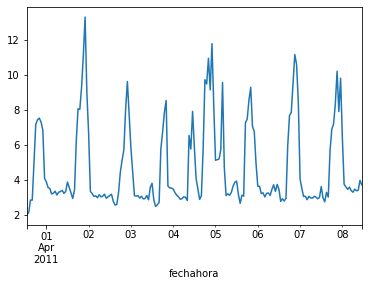

In [133]:
df['pot'].plot()

In [ ]:
# Pregunta 1 y 2
# ¿Cuál es el consumo (en kWh) del día tipo laboral según las mediciones de la primera semana abril? Respuesta:
#  RESPUESTA
# abril
df=df.loc['2011-04']
# primera semana
df=df.head(24*7)
ax = df[['pot']].plot( figsize=(15, 5))

In [ ]:
# media laborable
ll=df[['Hour','pot','dia_semana']].loc[df['Day'] < 5]
ll.reset_index(drop=True, inplace=True)
lll=ll.pivot(index='Hour',columns='dia_semana',values='pot')
lll['media']=lll.T.mean()
lll.plot( figsize=(15, 5))
# ll

In [ ]:
lll.sum().plot.bar()
lll.sum()

In [ ]:
# media laborable
ff=df[['Hour','pot','dia_semana']].loc[df['Day'] >= 5]
ff.reset_index(drop=True, inplace=True)
fff=ff.pivot(index='Hour',columns='dia_semana',values='pot')
fff['media']=fff.T.mean()
fff.plot( figsize=(15, 5))
# ll

In [ ]:
fff.sum().plot.bar()
fff.sum()

In [ ]:
bb=aa.mean().unstack(level=0)
bb.plot()
aa

In [ ]:
df

In [ ]:
aa=df[['pot']].resample('D').sum()
ax = aa.plot.bar(figsize=(15, 6))
aa

In [ ]:
aa=df0.groupby([df0.index.hour, 'weekday'])['Active power/Phase III +'].sum().unstack()
aa.plot()

In [ ]:
df['weekday'].isin({5, 6})

In [ ]:
L=[0,1,2,3,4]
F=[5,6]
aa['mediaL']=aa[L].T.median()
aa['mediaF']=aa[F].T.median()

aa

In [ ]:
aa[['mediaL','mediaF']].plot()

In [ ]:
df['weekday'] = df.index.weekday
df['weekend'] = df['weekday'].isin({5, 6})
df.groupby(['weekend', df0.index.hour])['Active power/Phase III +'].mean().unstack(level=0).plot()

In [ ]:
# terminar por tramos horarios
aa=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +'].loc['2011-04-02']
bb=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +'].loc['2011-04-04']

In [ ]:
# aa


In [ ]:
# terminar por tramos horarios
ax=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +'].loc['2011-04-02'].plot()
ax=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +'].loc['2011-04-04'].plot()

In [ ]:
aa=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +'].resample('D')
# ax=aa.plot()
aa


In [ ]:
aaa=df0[(df0.index.hour > 13) & (df0.index.hour <=22)]['Active power/Phase III +']
aaa

In [ ]:
ax=df0[(df0.index.hour > 4) & (df0.index.hour <=13)]['Active power/Phase III +'].resample('D').plot()


In [ ]:
ax=df0[(df0.index.hour > 22) & (df0.index.hour <=24) | (df0.index.hour > 0) & (df0.index.hour <=4)]['Active power/Phase III +'].resample('D').plot()


In [ ]:
aa=df0[['Active power/Phase III +']].resample('D').mean()
aa.index.day_name

In [ ]:
aa= df0[['Active power/Phase III +']].mean()
aa

In [ ]:
aa= df0[['Active power/Phase III +']].resample('D').mean()
dd=aa.describe()
ax =aa.plot.bar( figsize=(15, 6))
dd
# print(df0['Active power/Phase III +'].resample('D').mean())


In [ ]:
aa.plot(kind='pie', figsize=(6, 6),subplots=True)

In [ ]:
ax = df0[['Active power/Phase III +']].resample('D').sum().plot.bar( figsize=(15, 6), subplots=False)

In [ ]:
ax = df0[['Active power/Phase III +']].resample('D').sum().plot.bar( figsize=(15, 6), subplots=False)


In [ ]:
ax = df0[['Active power/Phase III +']].resample('8H').sum().plot.bar( figsize=(15, 6), subplots=False)


In [ ]:
def feature_holidays(row):

    if row["Drop_me"] == "01-01":
        return "New Year"
    if row["Drop_me"] == "04-07":
        return "Ind Day"
    if row["Drop_me"] == "11-28":
        return "Thanksgiving"
    if row["Drop_me"] == "12-25":
        return "Christmas"
    return 'Other'
def feature_worktime(row):
    if row["Hour"] > 7 & row["Hour"] <= 17:
        return "Worktime"
    return "NonWorkTime"
def feature_peak(row):
    if row["Hour"] > 7 & row["Hour"] <= 22:
        return "Peak"
    return "NonPeak"
def feature_weekend(row):
    if row["Day"] == 5 or row["Day"] == 6:
        return "Weekend"
    return "NonWeekend"

In [ ]:
df["Holiday"] = df.apply (lambda row : feature_holidays(row), axis=1)
df["Work"] = df.apply(lambda row: feature_worktime(row), axis=1)
df["Peak"] = df.apply(lambda row: feature_peak(row), axis=1)
df["Weekend"] = df.apply(lambda row: feature_weekend(row), axis=1)

In [ ]:
# suma de los cuadros
aa=df4[['Power/Triphasic +']].resample('D').sum().div(1000)
bb=df2[['Power/Triphasic +']].resample('D').sum().div(1000)
cc=dfA[['Power/Triphasic +']].resample('D').sum().div(1000)
aabbcc = aa.join(bb, how='outer',lsuffix='_left', rsuffix='_right').join(cc, how='outer',lsuffix='_left', rsuffix='_right')
aabbcc

In [ ]:
aabbcc.plot.bar( figsize=(15, 6),stacked=True, subplots=False)

In [ ]:
ax = df0[['Reactive power C/Phase III +']].plot( figsize=(15, 6), subplots=False)
ax.set_ylabel('KWh');
tt='Consumo mensual por periodos'



In [ ]:

# ====================================================
# ====================================================
# ## tt='estadisticos por periodos'
ax = df['pot'].resample('D').sum().plot.bar(figsize=(15, 6))
tt='estadisticos por periodos'



In [ ]:





# ====================================================
# ====================================================
# tt='estadisticos por periodos'
ax = df[columnas].boxplot(  figsize=(15, 6),  showmeans=True)
tt='estadisticos por periodos'
# ====================================================
ax.set_ylabel('KWh');
ax = plt.suptitle(tt)
plt.savefig(img, format='png')
img.seek(0)
imgb64 = base64.b64encode(img.getvalue()).decode()
f2 = ('<img src="data:image/png;base64,{}">'.format(imgb64))
plt.close()
# ====================================================


# ====================================================
# ====================================================
# tt='historgramas por periodos'
ax=df[columnas].hist(bins=10,linestyle='None', figsize=(15, 16))
tt='historgramas por periodos'
# ====================================================
ax = plt.suptitle(tt)
plt.savefig(img, format='png')
img.seek(0)
imgb64 = base64.b64encode(img.getvalue()).decode()
f3 = ('<img src="data:image/png;base64,{}">'.format(imgb64))
plt.close()
# ====================================================


# tablas
t01=df[columnas].resample('Y').sum()
t02=df[columnas].resample('Y').sum().apply(lambda x: 100 * x / float(x.sum())).round(1)
t03=df.describe().round(0)



In [ ]:
t03=df.describe().round(0)
t03

In [ ]:
# $$
# \boxed {SB-0/QGC} 
# \rightarrow
# \left \{
# \begin{array} \\
# \rightarrow \boxed {SB-A}\ ALTILLO \\
# \rightarrow \boxed {SB-1}\ FRIO \\
# \rightarrow \boxed {SB-2}\ OFICINAS \\
# \rightarrow \boxed {SB-3}\ MAQUINARIA \\
# \end{array}
# \right.
# $$

In [ ]:


# df


df['dxm'] = pd.DatetimeIndex(df.index).daysinmonth
# df
# df = pd.DataFrame({'date' : pd.date_range('20120101',periods=15,freq='M') })
# df['year'] = df['date'].dt.year
# df['month'] = df['date'].dt.month
# df['days_in_month'] = df['date'].dt.daysinmonth
# df
# df['year'] = df['fecha'].dt.year
# df['fecha']

# df=df[["P1","P2","P3","diasmes"]]
# df
# df.groupby(['fecha']).mean()
# df.describe()
df["P1"]=df.p1+df.p4
df["P2"]=df.p2+df.p5
df["P3"]=df.p3+df.p6

dfa=df[["P1","P2","P3"]]
dfa = dfa.cumsum(axis = 0).iloc[[-1]]
# dfa['$\Sigma{Pi}$']=dfa.P1+dfa.P2+dfa.P3
dfa_d=dfa.describe().round(0)
# dfa_c=dfa.cov()

#anual
tt='Consumo por periodo anual de electricidad del edificio período 2011-12/2012-11'
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax= dfa.plot.bar(ax=ax)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")


img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()

dfat=dfa.T
# dfatt=dfat.rename(columns={'fecha':'a'}, inplace=True)
dfat['Porcentaje'] = round(dfat.iloc[:, 0] /dfat.iloc[:, 0].sum()*100,1)
dfat_p=dfat[['Porcentaje']]
dfat_maximo = dfat['Porcentaje'].max()
dfat_periodo = dfat['Porcentaje'].idxmax()



df["Pi"]=df.P1+df.P2+df.P3
# df


#anual
df["laborable"]=df.p1+df.p2+df.p3
df["festivo"]=df.p4+df.p5+df.p6

dfal=df[["laborable","festivo"]]
dfal = dfal.cumsum(axis = 0).iloc[[-1]]
# dfal['$\Sigma{Pi}$']=dfal.L+dfal.F
dfal_d=dfal.describe().round(0)

tt='Consumo por laboralidad anual de electricidad del edificio período 2011-12/2012-11'
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax= dfal.plot.bar(ax=ax)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")


img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfal_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()


dfalt=dfal.T
# dfatt=dfat.rename(columns={'fecha':'a'}, inplace=True)
dfalt['Porcentaje'] = round(dfalt.iloc[:, 0] /dfalt.iloc[:, 0].sum()*100,1)
dfalt_p=dfalt[['Porcentaje']]
dfalt_maximo = dfalt['Porcentaje'].max()
dfalt_periodo = dfalt['Porcentaje'].idxmax()



df["Pi"]=df.P1+df.P2+df.P3
# df



# mensual
tt='Consumo mensual del edificio período 2011-12/2012-11'
dfm=df[["Pi"]]
dfm_d=dfm.describe().round(0)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax= dfm.plot.bar(ax=ax)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfm_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()

dfmt=dfm
# dfatt=dfat.rename(columns={'fecha':'a'}, inplace=True)
dfmt['Porcentaje'] = round(dfmt.iloc[:, 0] /dfmt.iloc[:, 0].sum()*100,1)
dfmt_p=dfmt[['Porcentaje']]
dfmt_maximo = dfmt['Porcentaje'].max()
dfmt_periodo = dfmt['Porcentaje'].idxmax()
datee = datetime.datetime.strptime(dfmt_periodo, "%Y-%m-%d")
dfmt_mes=datee.month


tt='Consumo total mensual del edificio per período de facturación 2011-12/2012-11'
dfmp=df[['P1','P2','P3']]
dfmp_d=dfmp.describe().round(0)
dfmp_c=dfmp.cov()

f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax= dfmp.plot.bar(ax=ax)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfmp_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()


# horario por periodos de facturacion
# tarifa 3.0
valle=8
punta=4
llano=12
# 
df["P1h"]=df.P1*df.dxm/punta
df["P2h"]=df.P2*df.dxm/llano
df["P3h"]=df.P3*df.dxm/valle
dfmh=df[['P1h','P2h','P3h']]
# dfmh

tt='Consumo horario por cada período mensual del edificio per período de facturación 2011-12/2012-11'
dfmh_d=dfmh.describe().round(0)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = dfmh.plot.bar(ax=ax)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")
img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfmh_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()
dfh=df[['p1','p2','p3']]
# dfh

In [ ]:
# precio potencia
ee1=0.111585986 # €/kW día
ee2=0.066951589 # €/kW día
ee3=0.044634397 # €/kW día


df_modulo=pd.read_csv("datos/efe1-precioconsumo1.csv", index_col=0, header=0)
df["exkwh1"]=df_modulo.exkwh

df_modulo=pd.read_csv("datos/efe1-precioconsumo2.csv", index_col=0, header=0)
df["exkwh2"]=df_modulo.exkwh

df_modulo=pd.read_csv("datos/efe1-precioconsumo3.csv", index_col=0, header=0)
df["exkwh3"]=df_modulo.exkwh


df_modulo=pd.read_csv("datos/efe1-preciopotencia.csv", index_col=0, header=0)
df["exkw"]=df_modulo.exkw
# df
pp=139 #kw
eep=0.087539 # e/(kw dia)

eeimpuesto=1.05113*4.864/100
eedescuentocliente=6/100
eeiva=0.18



df["eeconsumo1"]=df.P1*df.exkwh1
df["eeconsumo2"]=df.P2*df.exkwh2
df["eeconsumo3"]=df.P3*df.exkwh3
df["Termino_de_energia"]=df.eeconsumo1+df.eeconsumo2+df.eeconsumo3


df["Descuento"]=df.Termino_de_energia*eedescuentocliente
df["eefactura"]=df["eeconsumo1"]+df["eeconsumo2"]+df["eeconsumo3"]-df["Descuento"]

df["Termino_de_potencia"]=pp*df.dxm*df.exkw

df["antesimpuesto"]=df.Termino_de_energia-df.Descuento+df.Termino_de_potencia

df["Impuesto_electricidad"]=df["antesimpuesto"]*eeimpuesto

df["eefactura2"]=df["eefactura"]+df["Impuesto_electricidad"]+df["Termino_de_potencia"]

df["IVA"]=df["eefactura2"]*0.18
df["Total"]=df["eefactura2"]+df["IVA"]


# 
# 
dfee=pd.DataFrame()
dfea=pd.DataFrame()
dfem=pd.DataFrame()

dfee=df[["Termino_de_energia","Descuento","Termino_de_potencia","Impuesto_electricidad","IVA"]]
# dfee.round(2)
# 
tt='Costes eléctricos mensuales por conceptos facturados.'
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = dfee.plot.bar(ax=ax,stacked=True)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")
img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dcem_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()

# 
tt='Costes eléctricos anuales por conceptos facturados.'

dfa=dfee
dfa = dfa.cumsum(axis = 0).iloc[[-1]]
dfa_d=dfa.describe().round(0)
# dfa_c=dfa.cov()

#anual
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax= dfa.plot.bar(ax=ax,stacked=True)
ax = plt.suptitle(tt)
ax = plt.ylabel("kwh")


img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()




P1=0.111585986 # €/kW día
P2=0.066951589 # €/kW día
P3=0.044634397 # €/kW día

df_modulo=pd.read_csv("datos/efe1-m1.csv", index_col=0, header=0)
df["pm1"]=df_modulo.kw

df_modulo=pd.read_csv("datos/efe1-m2.csv", index_col=0, header=0)
df["pm2"]=df_modulo.kw

df_modulo=pd.read_csv("datos/efe1-m3.csv", index_col=0, header=0)
df["pm3"]=df_modulo.kw

# df[['pm1','pf1']]
yy=[]
xx=[]

for x in range(1, pp+1):
    pc=x
    df["pf1"]=where(df['pm1'] <  0.85*pc,pc,
                    where((df['pm1'] >= 0.85*pc) & (df['pm1'] <= 1.05*pc),df['pm1'],
                          where(df['pm1'] >  1.05*pc,df['pm1']+2*(df['pm1']-1.05*pc),0)))

    df["pf2"]=where(df['pm2'] <  0.85*pc,pc,
                    where((df['pm2'] >= 0.85*pc) & (df['pm2'] <= 1.05*pc),df['pm2'],
                          where(df['pm2'] >  1.05*pc,df['pm2']+2*(df['pm2']-1.05*pc),0)))

    df["pf3"]=where(df['pm3'] <  0.85*pc,pc,
                    where((df['pm3'] >= 0.85*pc) & (df['pm3'] <= 1.05*pc),df['pm3'],
                          where(df['pm3'] >  1.05*pc,df['pm3']+2*(df['pm3']-1.05*pc),0)))
    dfa = df[["pf1","pf2","pf3"]].cumsum(axis = 0).iloc[[-1]]
    dfa["total"]=dfa.pf1+dfa.pf2+dfa.pf3
    y=dfa["total"].iloc[[-1]].iloc[0]
    yy.append(y)
    xx.append(x)
# yy
dx=pd.DataFrame()
dx["Potencia_contratada"]=xx
dx["Coste_anual"]=yy

minimo = dx['Coste_anual'].min()
indice = dx['Coste_anual'].idxmin()
poptima=dx.loc[indice,"Potencia_contratada"]



maximo = dx['Coste_anual'].max()
indice = dx['Coste_anual'].idxmax()
pmax=dx.loc[indice,"Potencia_contratada"]
ahorro=maximo-minimo

tt='Optimización de potencia contratada'
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.plot(xx,yy)
ax = plt.suptitle(tt)
ax = plt.ylabel("Euros")
ax = plt.xlabel("kw")
img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
coste_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
plt.close()


In [ ]:
df[["pf1","pf2","pf3"]]
maximo

In [ ]:
139*3*12

# Pregunta 1
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Cuál es el consumo (en kWh) del día tipo laboral según las mediciones de la primera semana abril?
Respuesta: 121.289

# Pregunta 2
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Y uno festivo según las mediciones de la primera semana abril?

Responden en kWh.
Respuesta:97.538

# Pregunta 3
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Según las facturas que proporción del consumo eléctrico anual es en fin de semana en 2010?

Nota: Escribid el porcentaje sin %. Por ejemplo si os dos 70.5% escribid 70.5

 
Respuesta:
# Pregunta 4
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Qué índice energético habéis escogido para cada consumo? ¿Por qué?

Responded brevemente

 
	
Barra Toggle
		
Párrafo
	
		
	
		
	
		
	
	
Evitar vínculos automáticos
		
	
Insertar media Moodle
	
Ruta: p
# Pregunta 5
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

La potencia óptima a contratar seria de
Respuesta
kW que comportaría un ahorro anual de
Respuesta
€

Nota: suponemos la misma potencia de contratada en cada período y los valores de maxímetro de 2010.

Nota: El ahorro sin IVA ni impuesto eléctrico. Para calcular usar los precios de potencia de 2.014

 
# Pregunta 6
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Existió recargo por energía reactiva en 2010? ¿En caso afirmativo que sobrecoste tuvo?

Nota 1: si no existe recargo poned 0.

Nota2: Utilizad los valores de recargo actuales y poned la respuesta sin IVA ni impuesto eléctrico.

 
Respuesta:
# Pregunta 7
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

En 2010 el consumo del bar representó un
Respuesta
% del consumo eléctrico total y un
Respuesta
% del consumo de gas natural total.
# Pregunta 8
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Qué influencia tiene la climatización en el consumo eléctrico del edificio? ¿Y en
el consumo de gas natural? Calculad el coeficiente de correlación r2 de las de las dos
líneas base?

 a) Electricidad - Grados día:
Respuesta

 b) Combustible-Grados día  
Respuesta

 

Nota 1: Usad cuatro decimales.

Nota 2: Solo tenemos refrigeració de Abril a Setiembre y calefacción de Octubre a Marzo.

 
# Pregunta 9
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Qué aumento de consumo energético ha supuesto la obra de teatro respecto a un sábado normal?

Nota: Respuesta en kWh
Respuesta:
# Pregunta 10
Sin responder aún
Puntúa como 1,00
Marcar pregunta
Enunciado de la pregunta

¿Observáis en las mediciones o en la facturación algunos de los siguientes consumos ineficientes?
Seleccione una o más de una:

a. Consumos en horario matinal cuando el horario del centro es de tardes.

b. Consumos nocturnos cuando el centro está cerrado.

c. Puntas de potencia por encima de la contratada.

d. Fases con intensidad nula.

In [ ]:
%%html
<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value=" 
Curso:  Auditorías energéticas
Alumno: Francisco Manuel Roman Gamez

"></form>